In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
df = pd.read_csv("student-por.csv")
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [13]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [18]:
df.shape


(649, 33)

In [14]:
df.isnull().sum()


,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [15]:
df.fillna(df.mean(numeric_only=True), inplace=True)


In [16]:
df.isnull().sum()


,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [19]:
average_grades = df[['G1', 'G2', 'G3']].mean()
average_grades


,0
G1,11.399076
G2,11.570108
G3,11.906009


In [20]:
df['average_grade'] = df[['G1', 'G2', 'G3']].mean(axis=1)
df[['G1', 'G2', 'G3', 'average_grade']].head()


,G1,G2,G3,average_grade
0,0,11,11,7.333333
1,9,11,11,10.333333
2,12,13,12,12.333333
3,14,14,14,14.000000
4,11,13,13,12.333333


In [21]:
top_students = df.sort_values(by='average_grade', ascending=False).head(10)
top_students[['school', 'sex', 'studytime', 'average_grade']]


,school,sex,studytime,average_grade
338,GP,F,4,18.666667
636,MS,M,2,18.000000
606,MS,F,4,18.000000
332,GP,F,3,18.000000
594,MS,F,2,18.000000
349,GP,F,4,18.000000
617,MS,F,3,18.000000
596,MS,F,2,17.666667
549,MS,F,2,17.666667
337,GP,F,3,17.666667


In [22]:
corr_matrix = df[['studytime', 'failures', 'absences', 'G1', 'G2', 'G3']].corr()
corr_matrix


,studytime,failures,absences,G1,G2,G3
studytime,1.000000,-0.147441,-0.118389,0.260875,0.240498,0.249789
failures,-0.147441,1.000000,0.122779,-0.384210,-0.385782,-0.393316
absences,-0.118389,0.122779,1.000000,-0.147149,-0.124745,-0.091379
G1,0.260875,-0.384210,-0.147149,1.000000,0.864982,0.826387
G2,0.240498,-0.385782,-0.124745,0.864982,1.000000,0.918548
G3,0.249789,-0.393316,-0.091379,0.826387,0.918548,1.000000


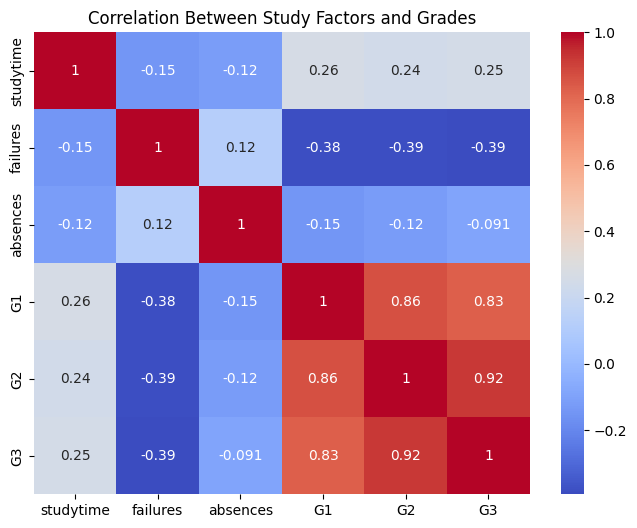

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Between Study Factors and Grades")
plt.show()


Insights

*  G1 and G2 have a strong positive correlation with final grad
*  Higher study time generally improves performance
*  Number of failures has a negative correlation with grades
*   Early academic performance strongly predicts final outcomes








